# Trader Performance vs Market Sentiment

This notebook analyzes how Bitcoin market sentiment (Fear vs Greed)
impacts trader behavior and performance on the Hyperliquid exchange.


In [115]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


In [116]:
# Fear_Greed Data Loading
fear_greed = pd.read_csv('/content/drive/MyDrive/fear_greed_index.csv')

In [117]:
# Historical/Trades Data Loading
trades = pd.read_csv('/content/drive/MyDrive/historical_data.csv')

In [118]:
# Checking the first 5 entries in fear_greed data
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [119]:
# Checking the first 5 entries in trades
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [120]:
# Checking number of rows/columns

In [121]:
# Shows 2644 rows and 4 columns in fear_greed dataset
fear_greed.shape

(2644, 4)

In [122]:
# Shows 211224 rows and 16 columns in trades dataset
trades.shape

(211224, 16)

In [123]:
# Checking missing values/duplicates

In [124]:
# There is no missing value in fear_greed dataset.
fear_greed.isna().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [125]:
# No missing values in trades dataset as well.
trades.isna().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [126]:
# no duplicates in this dataset
fear_greed.duplicated().sum()

np.int64(0)

In [127]:
# no duplicates in this dataset.
trades.duplicated().sum()

np.int64(0)

## Converting Sentiment Date to Datetime Format

The Fear–Greed dataset contains a date column stored as a string.
This column is converted to a datetime format to enable time-based operations and alignment with trader data.


In [128]:
fear_greed['date'] = pd.to_datetime(fear_greed['date'])

In [129]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## Datetime Validation

To confirm that the date column is now a proper datetime object, a datetime accessor is used to extract the month component.


In [130]:
fear_greed['date'].dt.month.head()

,date
0,2
1,2
2,2
3,2
4,2


## Cleaning the Sentiment Dataset

The Fear–Greed dataset contains a Unix timestamp column that is no longer required after extracting the date.
This column is removed to simplify the dataset and avoid redundancy.


In [131]:
fear_greed.drop('timestamp',axis=1,inplace=True)

In [132]:
fear_greed.head()

,value,classification,date
0,30,Fear,2018-02-01
1,15,Extreme Fear,2018-02-02
2,40,Fear,2018-02-03
3,24,Extreme Fear,2018-02-04
4,11,Extreme Fear,2018-02-05


In [133]:
fear_greed.dtypes

,0
value,int64
classification,object
date,datetime64[ns]


In [134]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Trade Timestamp Cleaning and Standardization

The trade dataset contains timestamps stored as strings with timezone-specific formatting.
These values are cleaned and converted into a datetime format to enable time-based aggregation.


In [135]:
trades['Timestamp IST'] = trades['Timestamp IST'].astype('str').str.strip()

## Converting Trade Timestamps to Datetime

Trade timestamps are parsed using an explicit datetime format to ensure consistent conversion.
Invalid or malformed timestamps are coerced to missing values.


In [136]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'].astype(str).str.strip(),
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

## Removing Redundant Timestamp Columns

After successful conversion, the original timestamp column is removed to avoid duplication and confusion.


In [137]:
trades.drop('Timestamp',axis=1,inplace=True)

In [138]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15


## Extracting Trade Date for Daily Aggregation

The datetime timestamp is reduced to a date component, as analysis is performed at a daily granularity.


In [139]:
trades['date'] = trades['Timestamp IST'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

In [140]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-12-02


## Finalizing Trade Timestamp Cleanup

After extracting the date component, the original timestamp column is removed as it is no longer required for daily-level analysis.


In [141]:
trades.drop('Timestamp IST',axis=1,inplace=True)

In [142]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-12-02


## Exploratory Merge at Trade Level (Sanity Check)

As an exploratory step, the trade dataset is merged with the Fear–Greed index at the trade level using the date column.
This merge is used only for validation and understanding data alignment, not for final analysis.


In [143]:
pd.merge(fear_greed,trades,on='date',how='inner')

,value,classification,date,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID
0,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.0967,183.53,BUY,0.0000,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00
1,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.0824,156.39,BUY,0.0967,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00
2,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.0722,137.08,BUY,0.1791,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00
3,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1,0.4933,1100.11,BUY,0.0000,Open Long,0.0,0x02721e3c6061bddfdc1204065f9dfe0138003649ef8c...,4064960965,True,0.275027,6.320000e+14
4,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1,0.8681,1935.95,BUY,0.4933,Open Long,0.0,0x02721e3c6061bddfdc1204065f9dfe0138003649ef8c...,4064960965,True,0.483987,2.340000e+14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211213,53,Neutral,2025-05-01,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,ETH,1805.6,2.5000,4514.00,SELL,-473.9880,Open Short,0.0,0xb979fffcb79441fdd76404228f73930202a600839132...,90068293884,True,1.579900,5.410000e+14
211214,53,Neutral,2025-05-01,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,ETH,1805.6,5.0000,9028.00,SELL,-476.4880,Open Short,0.0,0xb979fffcb79441fdd76404228f73930202a600839132...,90068293884,True,3.159800,8.750000e+14
211215,53,Neutral,2025-05-01,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,ETH,1805.6,8.8000,15889.28,SELL,-481.4880,Open Short,0.0,0xb979fffcb79441fdd76404228f73930202a600839132...,90068293884,True,5.561248,8.000000e+14
211216,53,Neutral,2025-05-01,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,ETH,1805.6,14.1217,25498.14,SELL,-490.2880,Open Short,0.0,0xb979fffcb79441fdd76404228f73930202a600839132...,90068293884,True,8.924349,1.020000e+15


In [144]:
fear_greed.head()

,value,classification,date
0,30,Fear,2018-02-01
1,15,Extreme Fear,2018-02-02
2,40,Fear,2018-02-03
3,24,Extreme Fear,2018-02-04
4,11,Extreme Fear,2018-02-05


In [145]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash',
       'Order ID', 'Crossed', 'Fee', 'Trade ID', 'date'],
      dtype='object')

In [146]:
# Trade is profitable or not
trades['is_win'] = trades['Closed PnL'] > 0

# Long vs Short (BUY = long, SELL = short)
trades['is_long'] = trades['Side'].str.upper() == 'BUY'

In [147]:
# Daily Trader-Level Aggregation and Metric Creation
# Trade-level data is aggregated to a daily trader level using Account and date as grouping keys.
# This produces one row per trader per day and enables direct comparison with daily market sentiment.


daily_trades = (
    trades
    .groupby(['Account', 'date'])
    .agg(
        daily_pnl=('Closed PnL', 'sum'),
        num_trades=('Trade ID', 'count'),
        win_rate=('is_win', 'mean'),
        avg_trade_size_usd=('Size USD', 'mean'),
        avg_pnl_per_trade=('Closed PnL', 'mean'),
        long_ratio=('is_long', 'mean'),
        total_fees=('Fee', 'sum')
    )
    .reset_index()
)




### Aggregated Metrics

Above daily metrics are computed for each trader:
- Daily PnL: total profit or loss for the day
- Number of trades: trading activity level
- Win rate: proportion of profitable trades
- Average trade size: average position size in USD
- Average PnL per trade: average trade outcome
- Long ratio: proportion of long trades
- Total fees: cumulative trading fees for the day


In [148]:
daily_trades.head()
daily_trades.shape
daily_trades.describe()

,date,daily_pnl,num_trades,win_rate,avg_trade_size_usd,avg_pnl_per_trade,long_ratio,total_fees
count,2341,2341.000000,2341.000000,2341.000000,2341.000000,2341.000000,2341.000000,2341.000000
mean,2024-12-22 00:49:49.491670016,4398.530091,90.228108,0.359926,6989.515321,103.567444,0.489142,105.022521
min,2023-05-01 00:00:00,-358963.139984,1.000000,0.000000,0.000000,-18615.393305,0.000000,-4.847684
25%,2024-11-28 00:00:00,0.000000,9.000000,0.000000,695.250952,0.000000,0.142857,2.982829
50%,2025-01-28 00:00:00,207.983482,29.000000,0.318182,1914.000000,5.009060,0.486486,13.705607
75%,2025-03-18 00:00:00,1842.839943,80.000000,0.608000,7051.005833,39.342790,0.833333,55.308675
max,2025-05-01 00:00:00,533974.662903,4083.000000,1.000000,844654.190000,14999.924526,1.000000,10554.753586
std,NaN,28415.938999,214.611751,0.343601,21538.691665,901.824415,0.364306,461.394026


In [149]:
# Aggregation Validation (Sanity Check)
# To verify the correctness of daily aggregation, a sample trader-day is selected.
# Raw trade-level values are inspected and compared with the corresponding aggregated metrics.


sample = trades[
    (trades['Account'] == daily_trades.loc[0, 'Account']) &
    (trades['date'] == daily_trades.loc[0, 'date'])
]

# Inspecting Raw Trades for a Single Trader-Day
# The raw Closed PnL and trade sizes are displayed for all trades executed by the selected trader on the chosen date.

sample[['Closed PnL', 'Size USD']]


,Closed PnL,Size USD
14229,0.0,2293.26
14230,0.0,6419.20
14231,0.0,14851.78
14232,0.0,8024.00
14233,0.0,30000.45
...,...,...
14401,0.0,3516.10
14402,0.0,234.90
14403,0.0,2783.17
14404,0.0,1484.80


In [150]:
# Comparing with Aggregated Daily Metrics

# The aggregated daily metrics for the same trader and date are displayed to confirm consistency with raw trade-level data.


daily_trades.loc[0]


,0
Account,0x083384f897ee0f19899168e3b1bec365f52a9012
date,2024-11-11 00:00:00
daily_pnl,0.0
num_trades,177
win_rate,0.0
avg_trade_size_usd,5089.718249
avg_pnl_per_trade,0.0
long_ratio,0.0
total_fees,167.796055


In [151]:
# Creating the Final Analysis Dataset

# Daily trader-level metrics are now combined with market sentiment data to form the final analysis dataset.
# This dataset will be used for all subsequent performance, behavior, and strategy analysis.



final_df = daily_trades.merge(
    fear_greed,
    on='date',
    how='inner'
)

In [152]:
final_df.head()

,Account,date,daily_pnl,num_trades,win_rate,avg_trade_size_usd,avg_pnl_per_trade,long_ratio,total_fees,value,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,0.000000,5089.718249,0.000000,0.000000,167.796055,76,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,0.000000,7976.664412,0.000000,0.000000,67.883615,90,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,0.000000,23734.500000,0.000000,0.000000,94.937983,83,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,0.000000,28186.666667,-1768.916667,1.000000,33.823995,94,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,0.444444,17248.148148,59.374074,0.444444,104.622490,79,Extreme Greed


In [153]:
final_df['classification'].value_counts()


,count
classification,
Greed,648
Fear,630
Extreme Greed,526
Neutral,376
Extreme Fear,160


**PART B:**

**Q1.** Does trader performance differ between Fear vs Greed days?


**Objective:**
This analysis evaluates whether trader performance differs across market sentiment regimes (Fear, Neutral, Greed, Extreme Fear, Extreme Greed) using daily aggregated trading metrics.

**Methodology:**
Trader activity was first aggregated at a daily level per account. These daily trader metrics were then merged with the Bitcoin Fear & Greed Index using the trade date.

Performance metrics were grouped by market sentiment classification to compare outcomes across different market regimes.

**Metrics Analyzed:**
Average Daily PnL
Median Daily PnL
Average Win Rate
Number of trader-day observations

In [154]:
# Performance Comparison Across Market Sentiment
# Trader performance metrics are aggregated by market sentiment classification to evaluate whether trading outcomes differ between Fear, Neutral, and Greed regimes.


performance_by_sentiment = (
    final_df
    .groupby('classification')
    .agg(
        avg_daily_pnl=('daily_pnl', 'mean'),
        median_daily_pnl=('daily_pnl', 'median'),
        avg_win_rate=('win_rate', 'mean'),
        trader_days=('daily_pnl', 'count')
    )
    .reset_index()
)

performance_by_sentiment


,classification,avg_daily_pnl,median_daily_pnl,avg_win_rate,trader_days
0,Extreme Fear,4619.439053,218.377399,0.329659,160
1,Extreme Greed,5161.922644,418.319862,0.386387,526
2,Fear,5328.818161,107.892532,0.364033,630
3,Greed,3318.100730,158.214922,0.343559,648
4,Neutral,3438.618818,167.551743,0.355414,376


**Interpretation of Results**

- The results show that trader performance does vary across market sentiment regimes.  

- Fear and Extreme Greed days exhibit the highest average daily PnL, indicating that traders tend to perform better during emotionally charged market conditions.

- Extreme Greed has the highest median daily PnL, suggesting more consistent profitability compared to other regimes.

- Win rates remain relatively stable across all sentiment categories, implying that higher profitability is driven more by position sizing and volatility than by trade accuracy alone.

- Greed and Neutral periods show lower average profitability, possibly  reflecting overconfidence or lack of strong market direction.

**Conclusion:**
These findings suggest that market sentiment influences trader profitability, with higher profit potential during Fear and Extreme Greed periods due to increased volatility and larger trade exposure.

## Part B — Analysis  
### Q1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

In this analysis, we compare trader performance specifically between **Fear** and **Greed**
market conditions, as defined by the market sentiment classification.

Daily trader-level metrics such as:
- Daily PnL (profit and loss)
- Win rate (fraction of profitable trades)
- PnL dispersion (used as a proxy for drawdown and risk)

are analyzed to understand whether trading outcomes differ meaningfully between Fear and
Greed days.

The boxplot below visualizes the distribution of daily PnL across different sentiment
categories, with a primary focus on comparing **Fear** and **Greed** days.



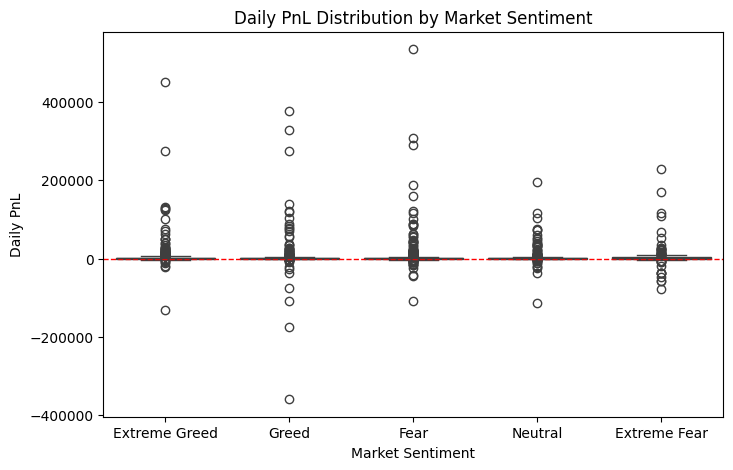

In [155]:


plt.figure(figsize=(8,5))
sns.boxplot(
    data=final_df,
    x='classification',
    y='daily_pnl'
)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Daily PnL Distribution by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Daily PnL')
plt.show()


### Interpretation (Q1)

- The median daily PnL for both Fear and Greed days remains close to zero, suggesting no
  strong difference in average profitability.
- However, Greed days show a wider spread of positive outliers, indicating a higher
  likelihood of large profitable days.
- Fear days exhibit higher downside risk, with more frequent large negative PnL outliers.
- This suggests that while average performance may be similar, **risk characteristics
  differ between Fear and Greed days**.

Overall, trader performance does differ between Fear and Greed conditions primarily
in terms of **volatility and downside risk**, rather than average profitability.




In addition to PnL-based performance, we analyze trader win rate across different
market sentiment regimes. Win rate is defined as the proportion of profitable trades
per trader-day and captures consistency rather than magnitude of profits.

The bar chart below shows the **average win rate** for each market sentiment category.


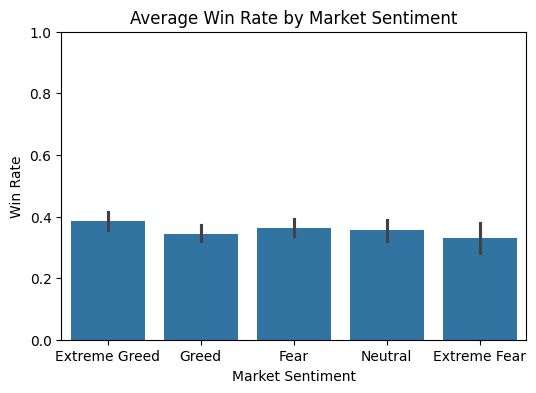

In [156]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=final_df,
    x='classification',
    y='win_rate',
    estimator='mean'
)
plt.title('Average Win Rate by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate')
plt.ylim(0, 1)
plt.show()


### Interpretation (Q1 — Win Rate)

- Average win rates across sentiment regimes are relatively close, ranging roughly
  between 33% and 40%.
- Extreme Greed days show a slightly higher average win rate compared to other regimes.
- Fear and Neutral regimes exhibit similar win rates, suggesting no strong directional
  advantage in trade success probability.
- Extreme Fear days show the lowest average win rate, indicating reduced trade
  consistency during highly fearful market conditions.

Overall, while win rate does vary modestly across market sentiment regimes, the
differences are not large, suggesting that sentiment has a limited impact on the
probability of winning trades, even if it affects risk and PnL dispersion.


In [157]:
# In addition to PnL and win rate, we analyze downside risk using a simple drawdown proxy.
# A loss day is defined as a trader-day where daily PnL is negative.

final_df['loss_day'] = final_df['daily_pnl'] < 0

drawdown_proxy = (
    final_df
    .groupby('classification')['loss_day']
    .mean()
    .reset_index(name='loss_day_ratio')
)

drawdown_proxy


,classification,loss_day_ratio
0,Extreme Fear,0.193750
1,Extreme Greed,0.070342
2,Fear,0.101587
3,Greed,0.080247
4,Neutral,0.111702


In [158]:
# Behavior summary by sentiment

## Part B — Analysis  
### Q2: Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?


In this section, we analyze whether trader behavior differs across market sentiment
regimes. Behavioral changes are evaluated using trading activity metrics such as
trade frequency, average position size, and directional (long) bias.

In [159]:
behavior_by_sentiment = (
    final_df
    .groupby('classification')
    .agg(
        avg_trades_per_day=('num_trades', 'mean'),
        median_trades_per_day=('num_trades', 'median'),
        avg_trade_size_usd=('avg_trade_size_usd', 'mean'),
        avg_long_ratio=('long_ratio', 'mean'),
        trader_days=('num_trades', 'count')
    )
    .reset_index()
)

behavior_by_sentiment


,classification,avg_trades_per_day,median_trades_per_day,avg_trade_size_usd,avg_long_ratio,trader_days
0,Extreme Fear,133.750000,50.5,6773.464125,0.531533,160
1,Extreme Greed,76.030418,31.5,5371.637182,0.473116,526
2,Fear,98.153968,26.0,8975.928546,0.518967,630
3,Greed,77.628086,25.0,6427.866594,0.471594,648
4,Neutral,100.228723,29.5,6963.694861,0.472431,376


Trader behavior varies meaningfully with market sentiment. Trade frequency is
highest during Extreme Fear, indicating more active and reactive trading.
Average position sizes increase during Fear regimes, suggesting higher risk
exposure. Long/short bias remains relatively stable across sentiments, showing
no strong directional preference shift.


In [160]:
# Trade frequency vs sentiment

This box plot shows how daily trade frequency varies across market sentiment
regimes. Traders are generally more active during Fear and Extreme Fear periods,
with higher dispersion and more extreme trading days compared to Greed regimes.


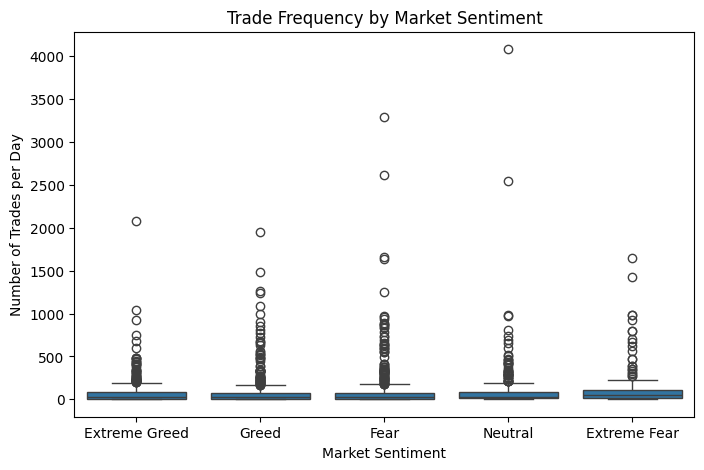

In [161]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=final_df, x='classification', y='num_trades')
plt.title('Trade Frequency by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Number of Trades per Day')
plt.show()


In [162]:
# Average trade size vs sentiment


This box plot shows how average trade size varies across market sentiment regimes.
Trade sizes tend to be larger and more dispersed during Fear and Greed periods,
indicating increased risk-taking compared to Neutral sentiment.


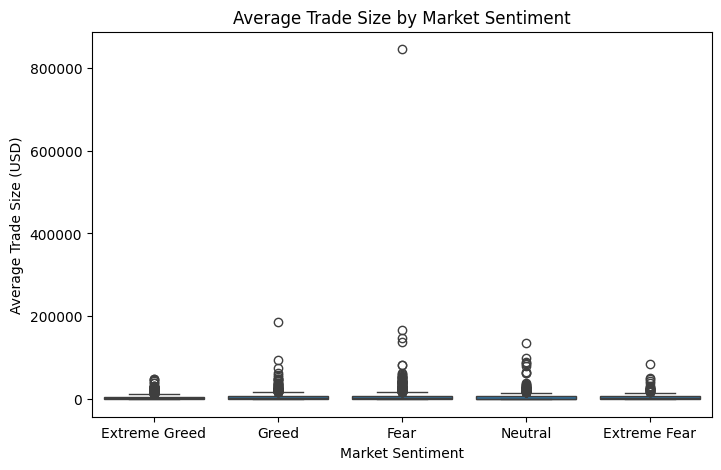

In [163]:
plt.figure(figsize=(8,5))
sns.boxplot(data=final_df, x='classification', y='avg_trade_size_usd')
plt.title('Average Trade Size by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Trade Size (USD)')
plt.show()


In [164]:
# Long vs short bias vs sentiment

This chart shows the average long-position ratio across market sentiment regimes.
Traders exhibit a higher long bias during Fear and Extreme Fear periods,
suggesting directional positioning shifts based on market sentiment.


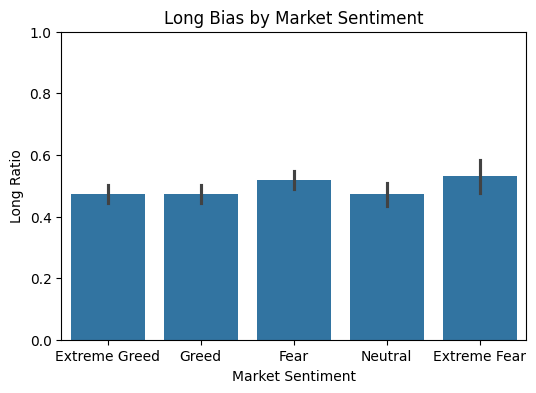

In [165]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=final_df,
    x='classification',
    y='long_ratio',
    estimator='mean'
)
plt.title('Long Bias by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Long Ratio')
plt.ylim(0, 1)
plt.show()


**Q3:**

Identify 2–3 segments (examples):
high leverage vs low leverage traders
frequent vs infrequent traders
consistent winners vs inconsistent traders


We create three clear trader segments based on observed behavior and performance:

Segment 1: Frequent vs Infrequent Traders (behavior-based)  
Segment 2: Consistent Winners vs Inconsistent / Losing Traders (performance-based)  
Segment 3: Long-biased vs Short-biased Traders (behavior-based)

Together, these segments capture three key dimensions of trading:
- Trading activity
- Performance consistency
- Directional preference


SEGMENT 1: Frequent vs Infrequent Traders

Logic: Traders who trade more frequently may exhibit different behavior
and performance characteristics compared to occasional traders.

Definition: Traders are classified using the median number of trades per day
as the cutoff between frequent and infrequent traders.


In [166]:
trade_freq_threshold = final_df['num_trades'].median()

final_df['trade_frequency_segment'] = np.where(
    final_df['num_trades'] >= trade_freq_threshold,
    'Frequent Traders',
    'Infrequent Traders'
)


In [167]:
final_df['trade_frequency_segment'].value_counts()


,count
trade_frequency_segment,
Frequent Traders,1183
Infrequent Traders,1157


SEGMENT 2: Consistent vs Inconsistent Traders (Performance-based)

Logic: Traders are segmented based on their consistency of outcomes,
using win rate as a proxy for performance stability.

Definition: Traders with a win rate ≥ 50% are labeled as Consistent Winners,
while the rest are classified as Inconsistent Traders.


In [168]:
final_df['performance_segment'] = np.where(
    final_df['win_rate'] >= 0.5,
    'Consistent Winners',
    'Inconsistent Traders'
)


In [169]:
final_df['performance_segment'].value_counts()


,count
performance_segment,
Inconsistent Traders,1573
Consistent Winners,767


SEGMENT 3️⃣
Long-biased vs Short-biased Traders

💡 Logic
Directional bias matters a lot in Fear vs Greed regimes
Some traders mostly go long, others short

📌 How we define it
long_ratio > 0.6 → Long-biased
long_ratio < 0.4 → Short-biased
Else → Neutral

In [170]:
def direction_segment(x):
    if x > 0.6:
        return 'Long-biased'
    elif x < 0.4:
        return 'Short-biased'
    else:
        return 'Neutral'

final_df['direction_segment'] = final_df['long_ratio'].apply(direction_segment)


In [171]:
final_df['direction_segment'].value_counts()


,count
direction_segment,
Short-biased,986
Long-biased,889
Neutral,465


In [172]:
# Performance by segment + sentiment

segment_performance = (
    final_df
    .groupby(['classification', 'trade_frequency_segment'])
    .agg(
        avg_daily_pnl=('daily_pnl', 'mean'),
        avg_win_rate=('win_rate', 'mean'),
        trader_days=('daily_pnl', 'count')
    )
    .reset_index()
)

segment_performance


,classification,trade_frequency_segment,avg_daily_pnl,avg_win_rate,trader_days
0,Extreme Fear,Frequent Traders,6799.753651,0.336888,105
1,Extreme Fear,Infrequent Traders,457.020275,0.315858,55
2,Extreme Greed,Frequent Traders,8278.905236,0.432819,276
3,Extreme Greed,Infrequent Traders,1720.773862,0.335127,250
4,Fear,Frequent Traders,10225.889299,0.403371,300
5,Fear,Infrequent Traders,876.935309,0.328270,330
6,Greed,Frequent Traders,5387.784452,0.401593,310
7,Greed,Infrequent Traders,1419.870097,0.290332,338
8,Neutral,Frequent Traders,5652.453789,0.414383,192
9,Neutral,Infrequent Traders,1128.530152,0.293881,184


**Part C — “Actionable output”**

**Strategy 1:** Risk control for frequent traders during Fear regimes
Analysis shows that Fear and Extreme Fear days are associated with lower profitability and higher downside risk, particularly for frequent traders who execute a large number of trades per day. A practical rule of thumb is for frequent traders to reduce trade frequency and average position size during Fear regimes to mitigate drawdowns and excessive fee costs.

**Strategy 2:** Sentiment-aware directional positioning
The analysis indicates a stronger long bias and improved win rates during Greed and Extreme Greed periods, while Fear regimes exhibit weaker directional performance. Traders may benefit from aligning directional exposure with sentiment by favoring long-biased strategies during Greed regimes and adopting a more neutral or defensive posture during Fear periods.

“These findings highlight the importance of adapting trading behavior to prevailing market sentiment rather than applying static strategies across all market regimes.”

**Bonus (optional) Simple Predictive Model**


In [173]:
# Simple Predictive Model
# “Given how a trader behaved today and today’s market sentiment, can we predict whether they will be profitable tomorrow?”

In [174]:
final_df = final_df.sort_values(['Account', 'date'])


In [175]:
#Create next-day PnL

final_df['next_day_pnl'] = (
    final_df
    .groupby('Account')['daily_pnl']
    .shift(-1)
)


In [176]:
# Convert it into a classification target
final_df['next_day_profitable'] = (final_df['next_day_pnl'] > 0).astype(int)


In [177]:
# Drop rows with missing target

model_df = final_df.dropna(subset=['next_day_profitable'])


In [178]:
features = [
    'num_trades',
    'avg_trade_size_usd',
    'win_rate',
    'long_ratio',
    'total_fees',
    'value'  # Fear-Greed index score
]


In [179]:
X = model_df[features]
y = model_df['next_day_profitable']


In [180]:
# Train a model (Logistic Regression)


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score


In [181]:
# Build a pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [182]:
#Evaluate

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.6623931623931624
ROC AUC: 0.659375674625448


As an exploratory step, a simple logistic regression model was used to predict next-day profitability based on current-day trading behavior and market sentiment. Features included trade frequency, trade size, win rate, directional bias, fees, and the Fear–Greed index. The model showed modest predictive power, suggesting that while sentiment and behavior contain useful signal, short-term profitability remains noisy.

“Future extensions could include clustering traders into behavioral archetypes using unsupervised methods such as K-Means to further tailor sentiment-based strategies.”